In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [77]:
dataset = pd.read_csv("../data/train.csv")
dataset = dataset.drop(columns=["Unnamed: 0"])
dataset['datetime'] = pd.to_datetime(
    dataset['Year'].astype(str) + '-' + 
    dataset['Decimal Day'].astype(str) + 
    ' ' + 
    dataset['Hour'].astype(str),
    format='%Y-%j %H'
)
dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
dataset = dataset[cols]
dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


In [78]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 210384 entries, 0 to 210383
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   datetime    210384 non-null  datetime64[us]
 1   Bz_GSM      210384 non-null  float64       
 2   By_GSM      210384 non-null  float64       
 3   Bx_GSE      210384 non-null  float64       
 4   Kp          210384 non-null  int64         
 5   f10.7       210384 non-null  float64       
 6   AL          210384 non-null  int64         
 7   AU          210384 non-null  int64         
 8   T_proton    210384 non-null  float64       
 9   Np_density  210384 non-null  float64       
 10  V_plasma    210384 non-null  float64       
 11  V_Long_GSE  210384 non-null  float64       
 12  V_Lat_GSE   210384 non-null  float64       
 13  Dst         210384 non-null  int64         
 14  AE          210384 non-null  int64         
dtypes: datetime64[us](1), float64(9), int64(5)
memory usage: 24.1 

In [79]:
dataset.describe()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
count,210384,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,2.103840e+05,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000,210384.000000
mean,2006-12-31 23:30:00,1.979221,2.080122,1.874579,18.441963,109.263963,-112.295911,68.111116,3.165466e+05,30.821627,457.463357,2.709679,2.247959,-13.242243,180.439758
min,1995-01-01 00:00:00,-57.800000,-43.100000,-40.800000,0.000000,64.600000,-2452.000000,-260.000000,3.299000e+03,0.100000,228.000000,-26.900000,-17.800000,-422.000000,3.000000
25%,2000-12-31 11:45:00,-1.500000,-2.400000,-2.600000,7.000000,74.200000,-153.000000,22.000000,3.719675e+04,3.100000,354.000000,-1.700000,-2.100000,-21.000000,47.000000
50%,2006-12-31 23:30:00,0.000000,0.000000,-0.100000,17.000000,94.100000,-52.000000,44.000000,7.052950e+04,4.900000,407.000000,-0.200000,-0.700000,-10.000000,100.000000
75%,2012-12-31 11:15:00,1.400000,2.500000,2.500000,27.000000,133.100000,-21.000000,92.000000,1.307762e+05,8.100000,486.000000,1.300000,0.700000,-1.000000,245.000000
max,2018-12-31 23:00:00,999.900000,999.900000,999.900000,90.000000,999.900000,22.000000,1226.000000,9.999999e+06,999.900000,9999.000000,999.900000,999.900000,77.000000,2241.000000
std,NaN,45.103057,45.158247,43.750043,13.617466,51.154913,143.558231,68.055577,1.467536e+06,154.353747,520.345100,53.485555,54.595549,20.120794,197.759337


In [87]:
dataset.isna().sum()

datetime      0
Bz_GSM        0
By_GSM        0
Bx_GSE        0
Kp            0
f10.7         0
AL            0
AU            0
T_proton      0
Np_density    0
V_plasma      0
V_Long_GSE    0
V_Lat_GSE     0
Dst           0
AE            0
dtype: int64

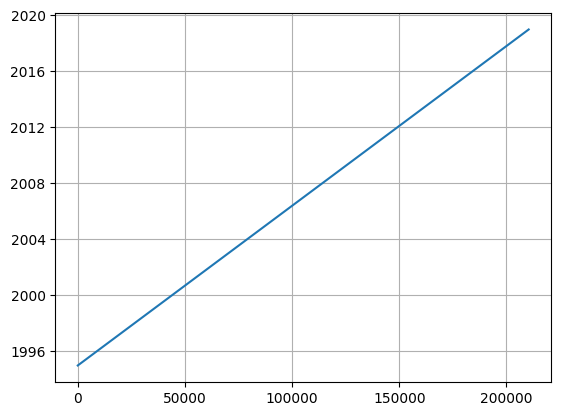

In [88]:
plt.plot(dataset["datetime"])
plt.grid();

### IMF - Interplanetary Magnetic Field (межпланетное магнитное поле)

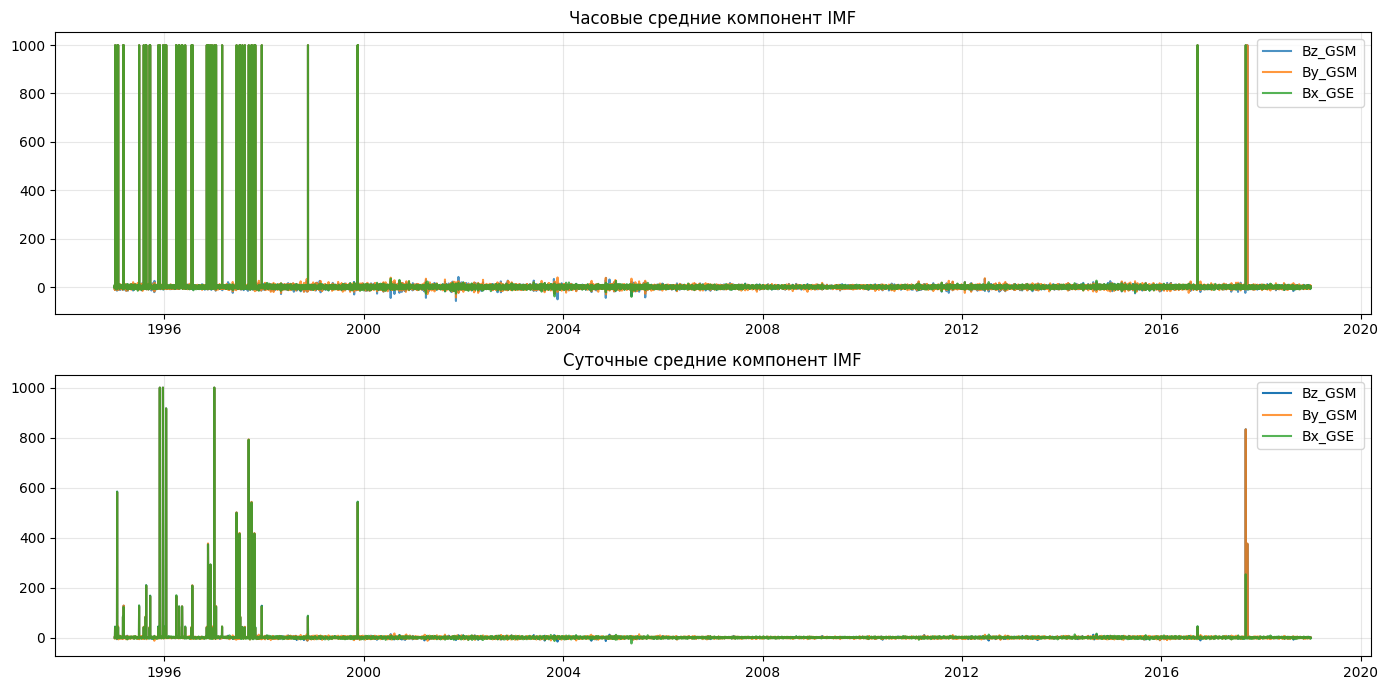

In [66]:
_, axis = plt.subplots(2, 1, figsize=(14, 7))

axis[0].set_title("Часовые средние компонент IMF")
axis[0].plot(dataset["datetime"], dataset["Bz_GSM"], alpha=0.8, label="Bz_GSM")
axis[0].plot(dataset["datetime"], dataset["By_GSM"], alpha=0.8, label="By_GSM")
axis[0].plot(dataset["datetime"], dataset["Bx_GSE"], alpha=0.8, label="Bx_GSE")
axis[0].grid(alpha=0.3)
axis[0].legend()

daily_data = dataset.set_index('datetime').resample('D').mean()
axis[1].set_title("Суточные средние компонент IMF")
axis[1].plot(daily_data.index, daily_data["Bz_GSM"], label="Bz_GSM")
axis[1].plot(daily_data.index, daily_data["By_GSM"], label="By_GSM", alpha=0.8)
axis[1].plot(daily_data.index, daily_data["Bx_GSE"], label="Bx_GSE", alpha=0.8)
axis[1].grid(alpha=0.3)
axis[1].legend()

plt.tight_layout()
plt.show()

In [100]:
def moving_average(x, k: int):
    if not isinstance(x, pd.Series):
        x = pd.Series(x)
    return x.rolling(k).mean()

In [142]:
def make_ts_plot_with_ma(feature: pd.Series, title, label, ma_k):
    feature_ma = moving_average(feature, k=ma_k)
    plt.figure(figsize=(14, 5))
    plt.title(title)
    plt.plot(feature.index, feature, label=label)
    plt.plot(feature_ma, label="MA 120 (сезонность)")
    plt.grid(alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

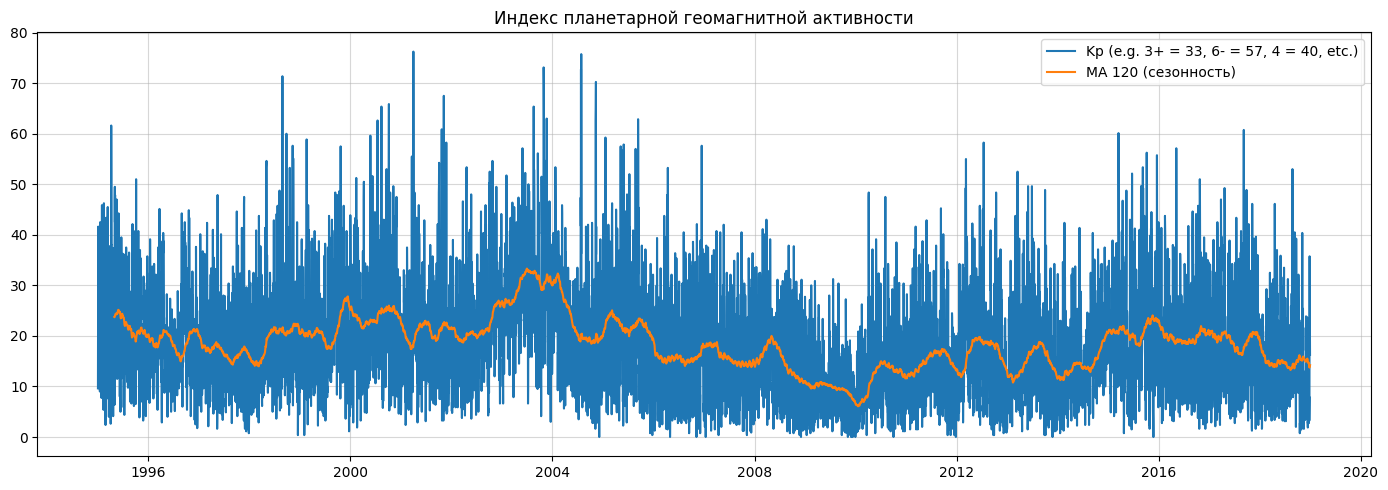

In [143]:
make_ts_plot_with_ma(
    feature=daily_data["Kp"],
    title="Индекс планетарной геомагнитной активности",
    label="Kp (e.g. 3+ = 33, 6- = 57, 4 = 40, etc.)",
    ma_k=120
)

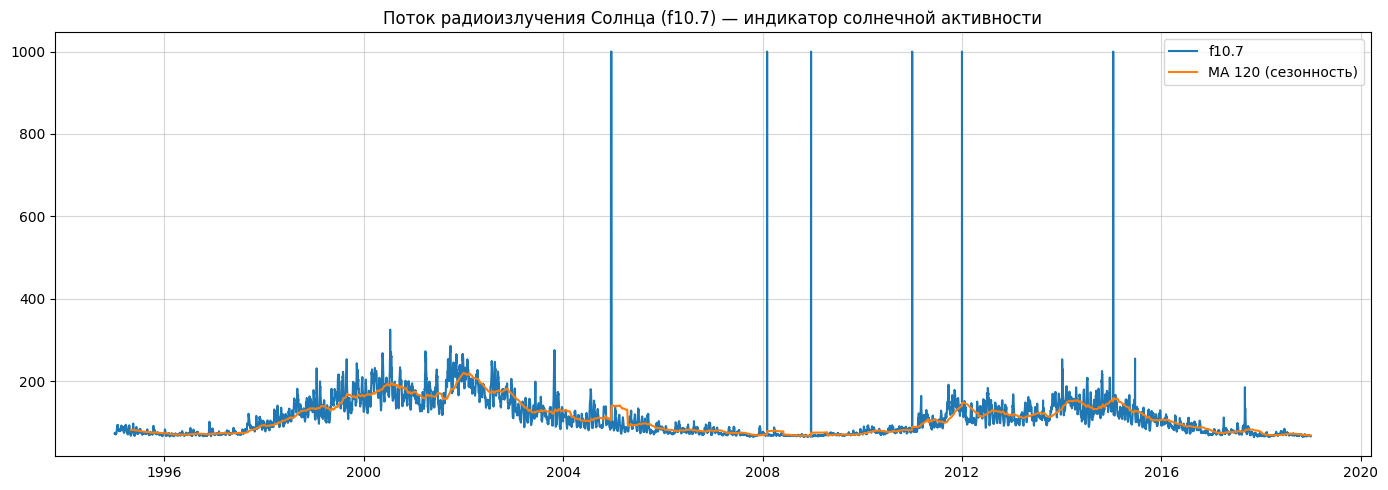

In [144]:
make_ts_plot_with_ma(
    feature=daily_data["f10.7"],
    title="Поток радиоизлучения Солнца (f10.7) — индикатор солнечной активности",
    label="f10.7",
    ma_k=120
)

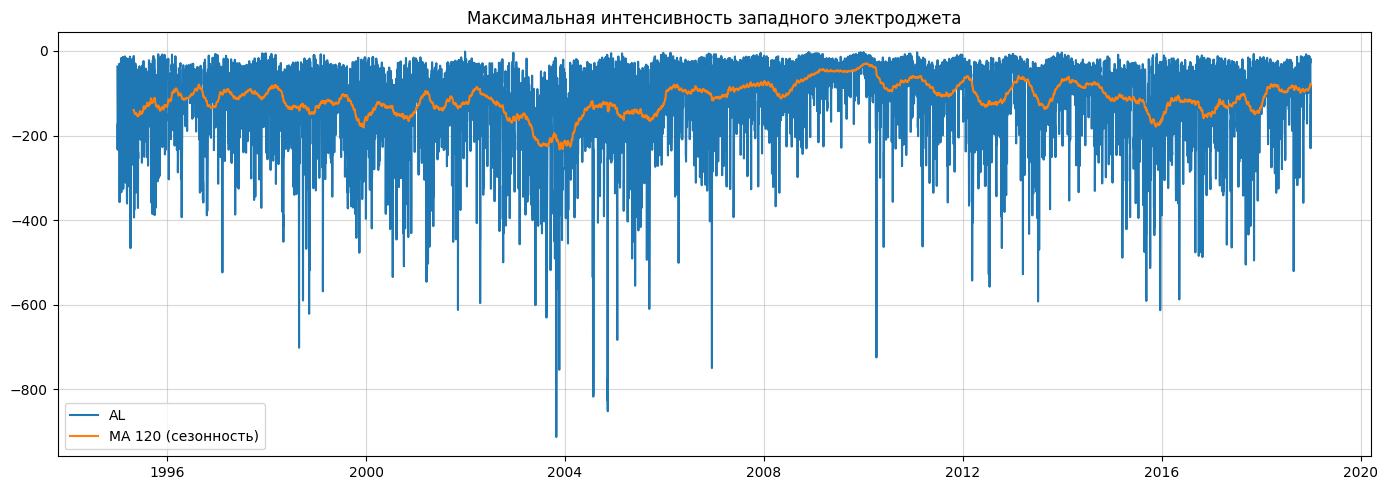

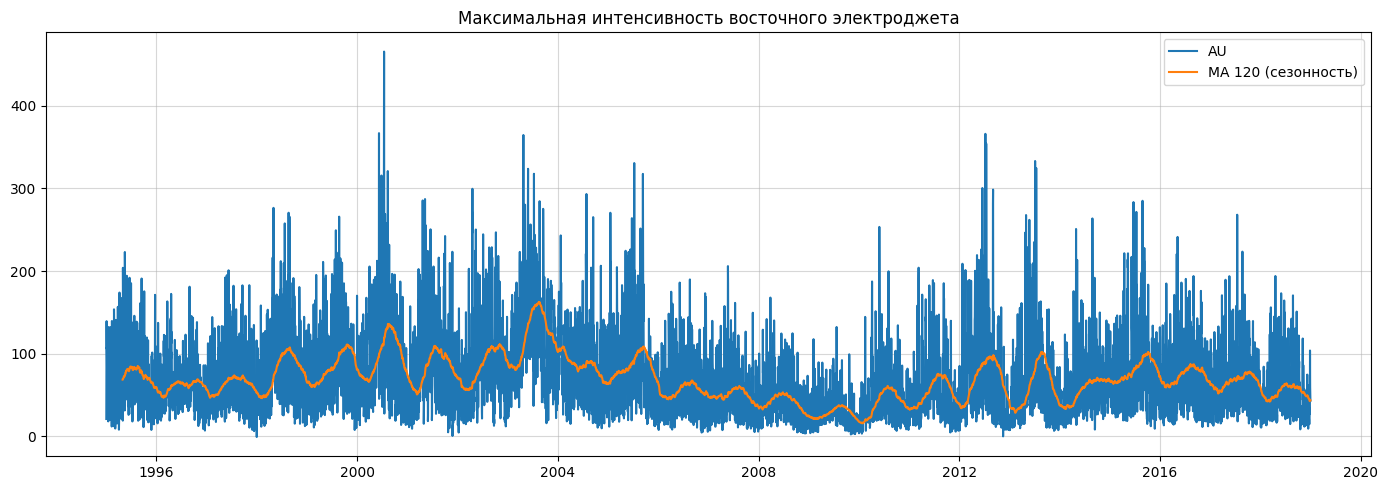

In [145]:
make_ts_plot_with_ma(
    feature=daily_data["AL"],
    title="Максимальная интенсивность западного электроджета",
    label="AL",
    ma_k=120
)
make_ts_plot_with_ma(
    feature=daily_data["AU"],
    title="Максимальная интенсивность восточного электроджета",
    label="AU",
    ma_k=120
)

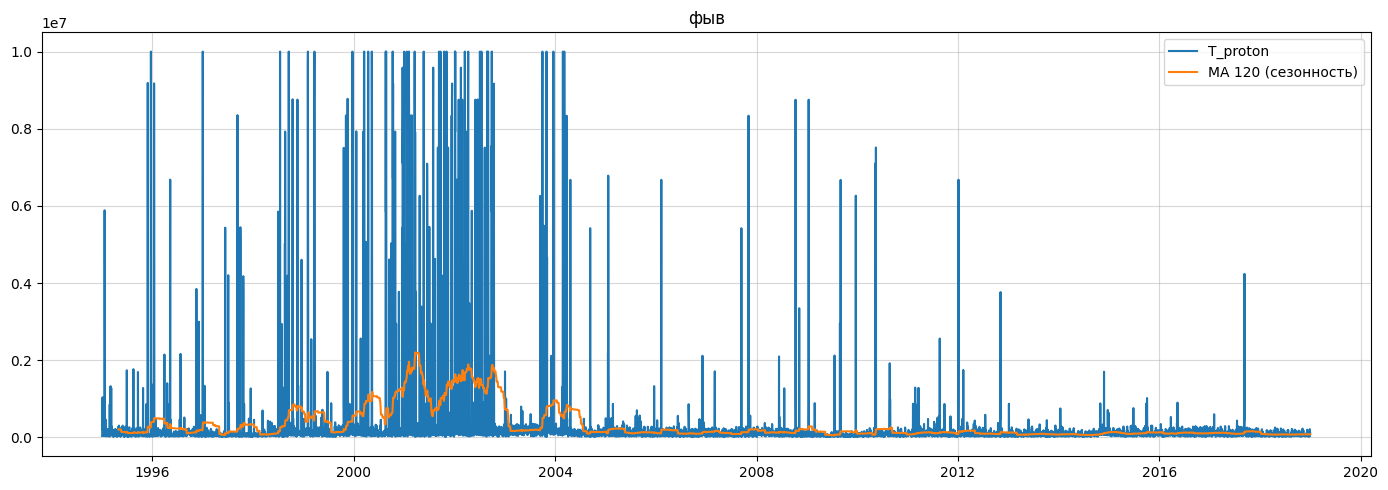

In [ ]:
make_ts_plot_with_ma(
    feature=daily_data["T_proton"],
    title="фыв",
    label="T_proton",
    ma_k=120
)

### Визуализация плазменных параметров солнечного ветра

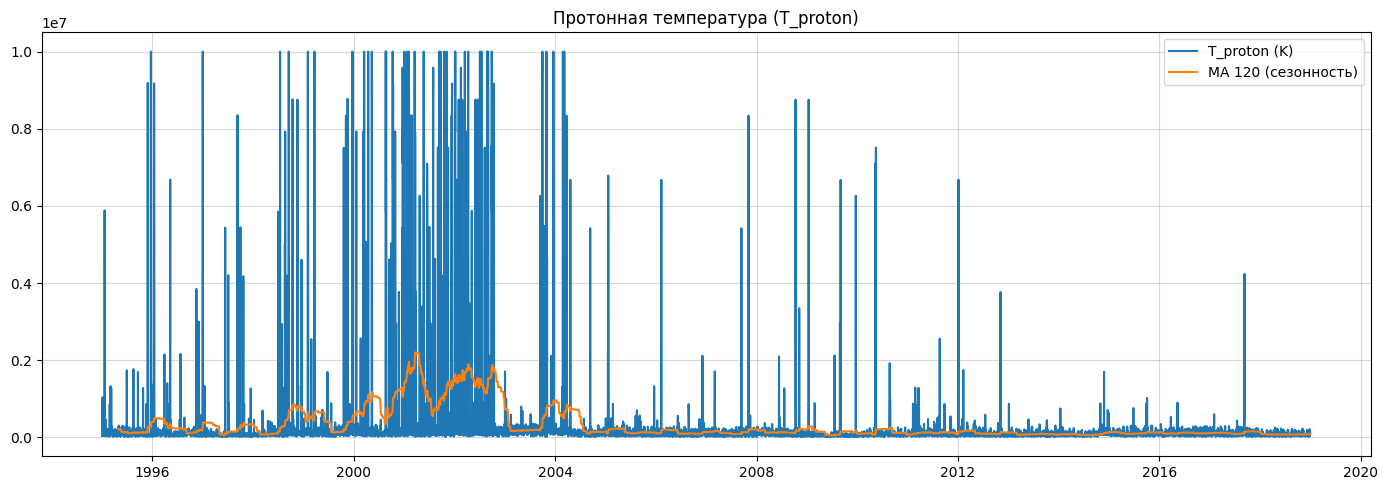

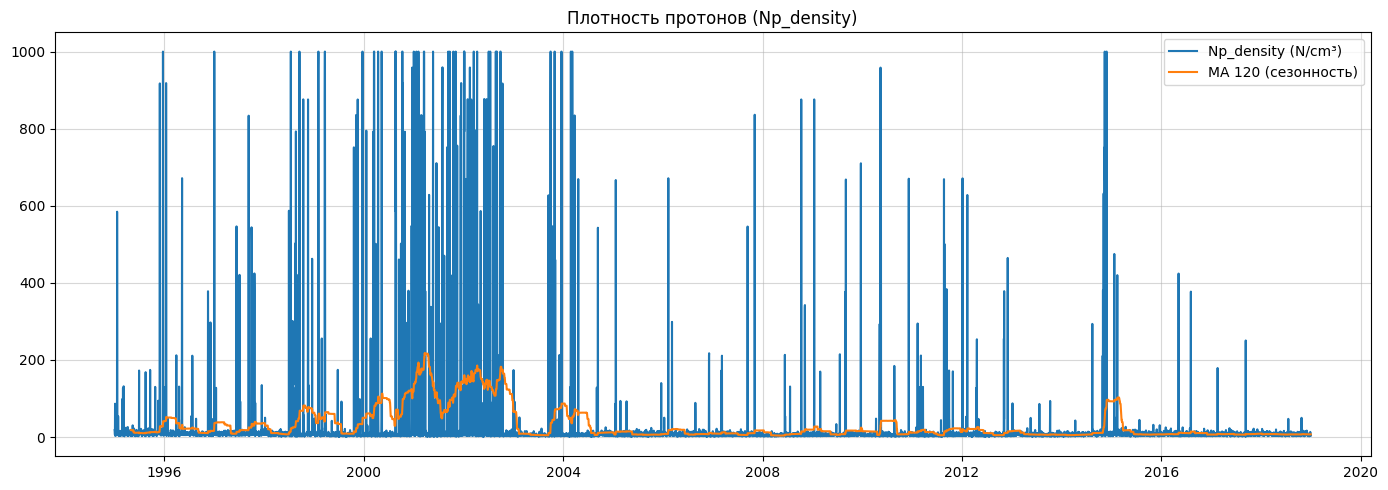

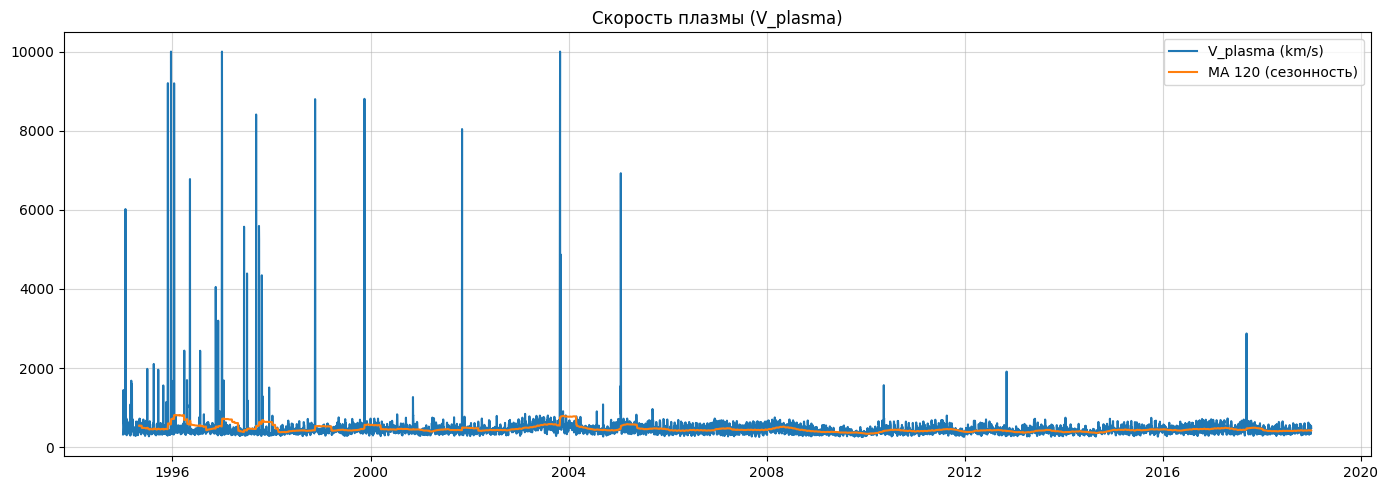

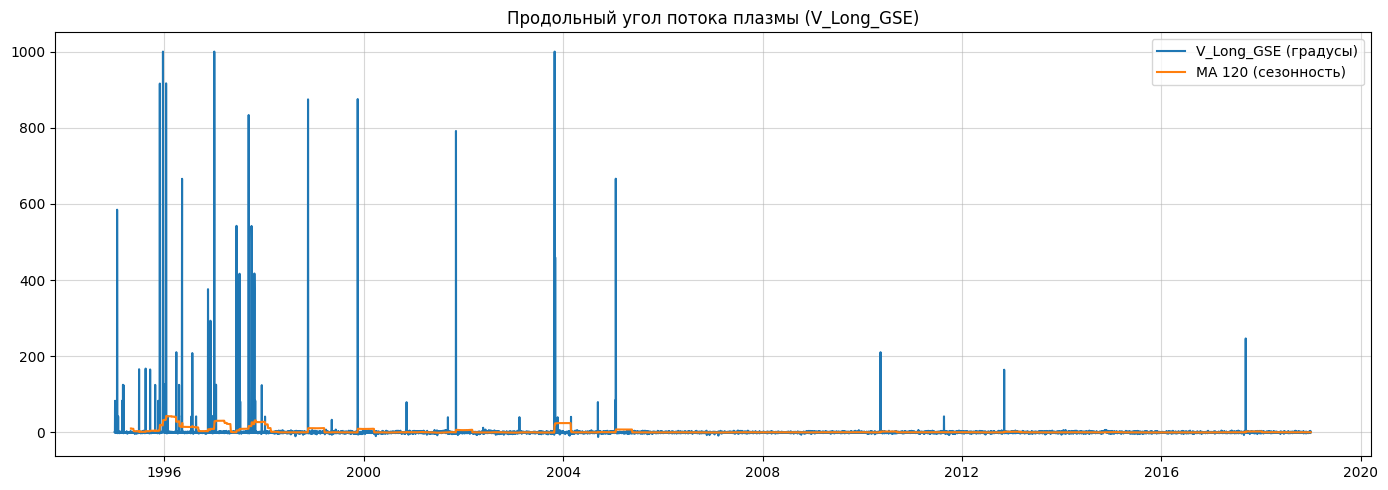

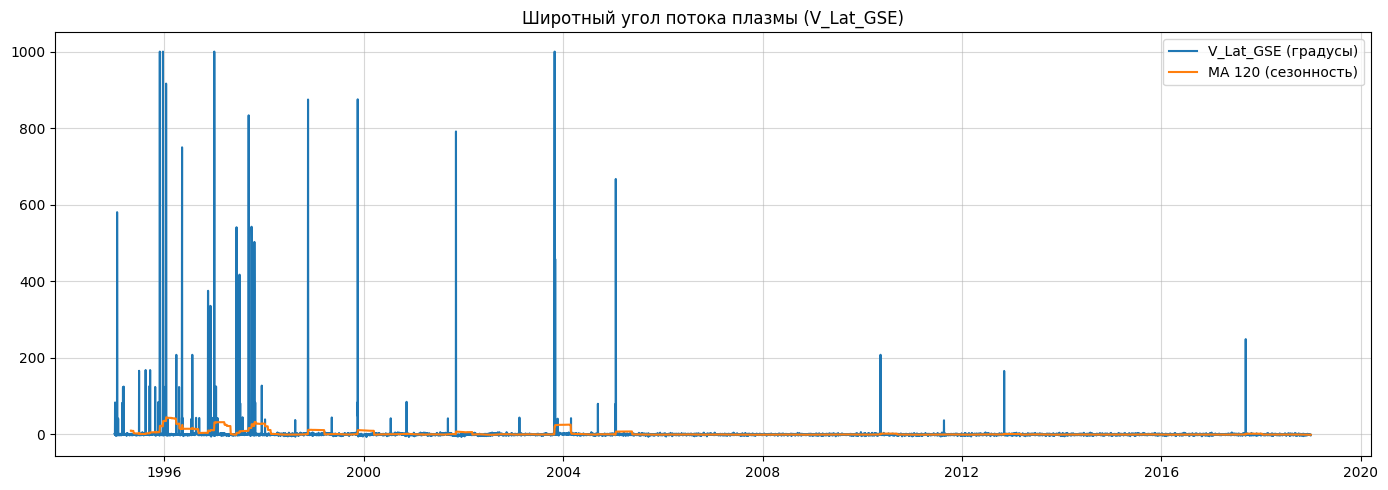

In [151]:
plasma_features = ['T_proton', 'Np_density', 'V_plasma', 'V_Long_GSE', 'V_Lat_GSE']
plasma_titles = [
    'Протонная температура (T_proton)',
    'Плотность протонов (Np_density)',
    'Скорость плазмы (V_plasma)',
    'Продольный угол потока плазмы (V_Long_GSE)',
    'Широтный угол потока плазмы (V_Lat_GSE)'
]
plasma_labels = ['T_proton (K)', 'Np_density (N/cm³)', 'V_plasma (km/s)', 'V_Long_GSE (градусы)', 'V_Lat_GSE (градусы)']

for feat, title, label in zip(plasma_features, plasma_titles, plasma_labels):
    make_ts_plot_with_ma(
        feature=daily_data[feat],
        title=title,
        label=label,
        ma_k=120,
    )